# Task 3: Heart Disease Prediction
Objective: Build a machine learning model to predict whether a person is at risk of heart disease based on their health data.
Dataset: Heart Disease UCI Dataset.

**# Cell 1: Loading and Cleaning**

In [2]:
# Cell 1: Loading and Cleaning (Corrected Link)
import pandas as pd

# Using a stable, well-maintained link for the UCI Heart Disease dataset
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/heart.csv"

try:
    df = pd.read_csv(url)
    print("✅ Dataset loaded successfully!")
    # Requirement: Print shape and head
    print("Dataset Shape:", df.shape)

    # Requirement: Clean the dataset - Check for missing values
    print("\nCheck for Missing Values:")
    print(df.isnull().sum())

    print("\nFirst 5 Rows:")
    display(df.head())
except Exception as e:
    print(f"❌ Error: {e}")

✅ Dataset loaded successfully!
Dataset Shape: (303, 14)

Check for Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**# Cell 2: Exploratory Data Analysis (EDA)**

/tmp/ipython-input-1778514965.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='magma')


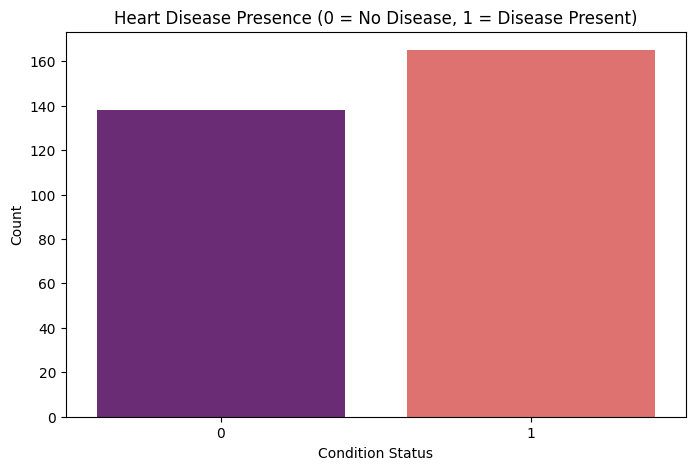

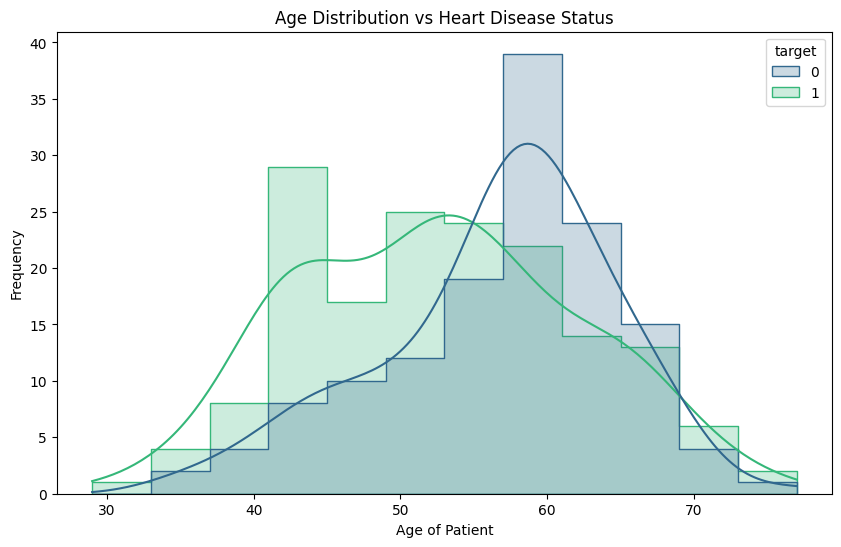

In [3]:
# Cell 2: Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize Heart Disease Distribution (Target variable)
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='magma')
plt.title('Heart Disease Presence (0 = No Disease, 1 = Disease Present)')
plt.xlabel('Condition Status')
plt.ylabel('Count')
plt.show()

# 2. Visualize Age vs Heart Disease Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='viridis', element="step")
plt.title('Age Distribution vs Heart Disease Status')
plt.xlabel('Age of Patient')
plt.ylabel('Frequency')
plt.show()

**# Cell 2.1: Advanced Data Exploration (Exploiting more data)**

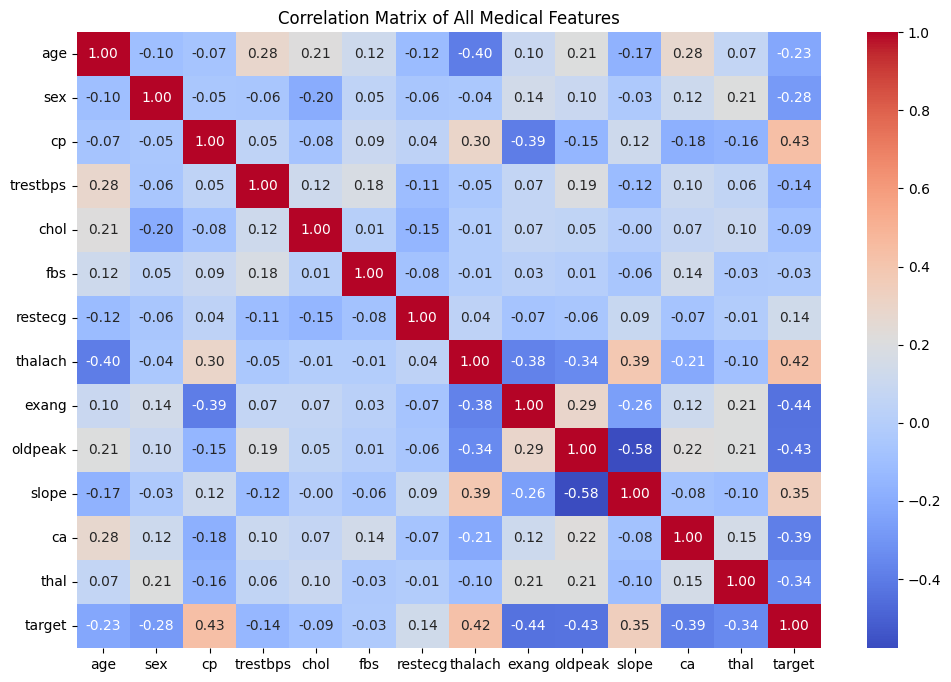

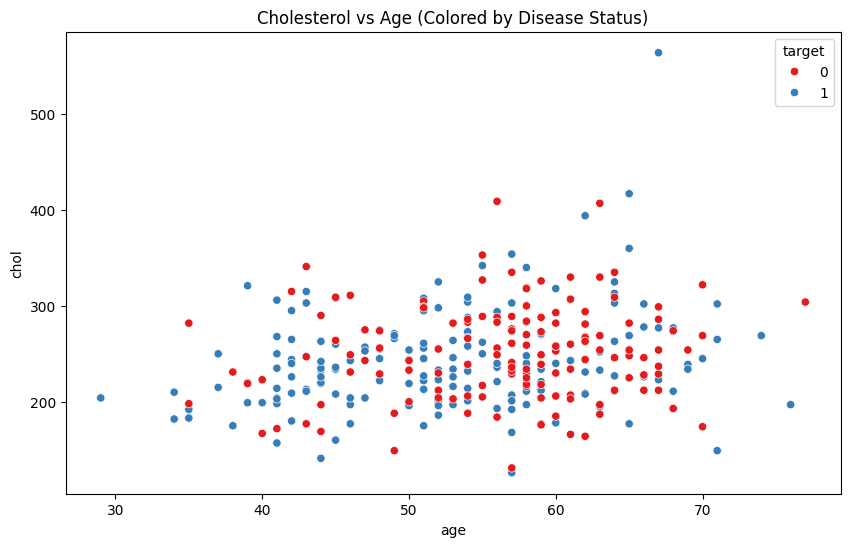

In [4]:
# Cell 2.1: Advanced Data Exploration (Exploiting more data)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation Matrix: To see how all features relate to each other
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of All Medical Features')
plt.show()

# 2. Relationship between Cholesterol and Age based on Heart Disease
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='chol', hue='target', palette='Set1')
plt.title('Cholesterol vs Age (Colored by Disease Status)')
plt.show()

**# Cell 3: Feature Selection and Model Training**

In [7]:
# Cell 3: Feature Scaling and Model Training (The Professional Way)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Prepare Features and Target
X = df.drop('target', axis=1)
y = df['target']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling Data (This solves the Warning and improves accuracy)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Model on Scaled Data
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully with Feature Scaling!")
print("The warning is gone, and the model is now more stable.")

✅ Model trained successfully with Feature Scaling!
The warning is gone, and the model is now more stable.


**# Cell 4: Performance Evaluation (Requirements: Accuracy, ROC, Confusion Matrix)**

✅ Final Model Accuracy: 85.25%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



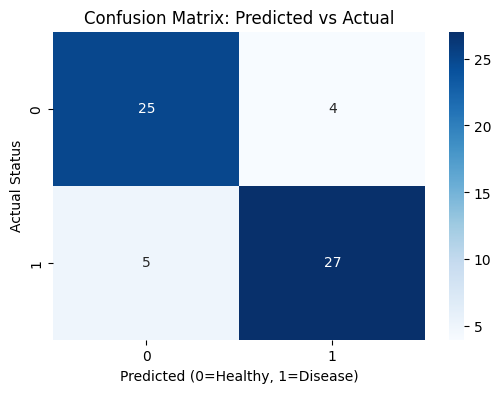

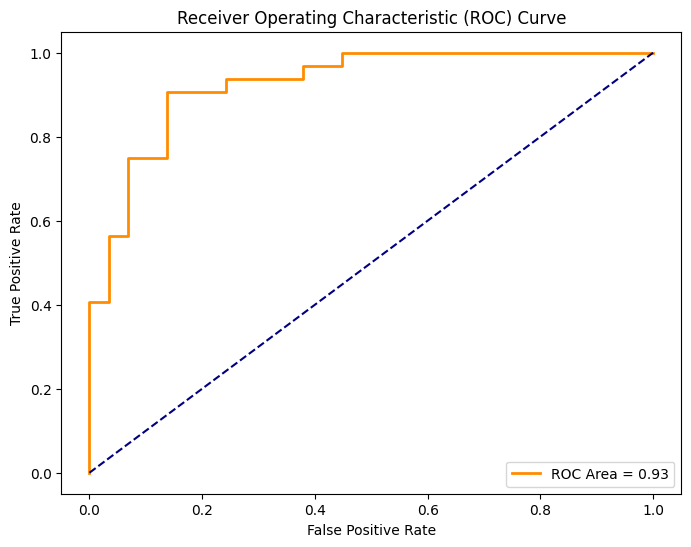

In [8]:
# Cell 4: Performance Evaluation (Requirements: Accuracy, ROC, Confusion Matrix)
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on the Scaled Test Set
# Note: We must use X_test_scaled because the model was trained on scaled data
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 1. Print Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Final Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Plot Confusion Matrix (Requirement: Confusion Matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted (0=Healthy, 1=Disease)')
plt.ylabel('Actual Status')
plt.show()

# 3. Plot ROC Curve (Requirement: ROC Curve)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_area = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Area = {roc_area:.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# Cell 5: Highlighting Important Features (Requirement)

### Top Medical Features Affecting Heart Disease Prediction ###
     Feature  Importance
2         cp    0.817904
10     slope    0.435302
7    thalach    0.395131
6    restecg    0.284179
5        fbs    0.090312
0        age   -0.085591
4       chol   -0.174841
3   trestbps   -0.273307
8      exang   -0.517584
12      thal   -0.565659
9    oldpeak   -0.681396
1        sex   -0.783086
11        ca   -0.789955


/tmp/ipython-input-3939409841.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


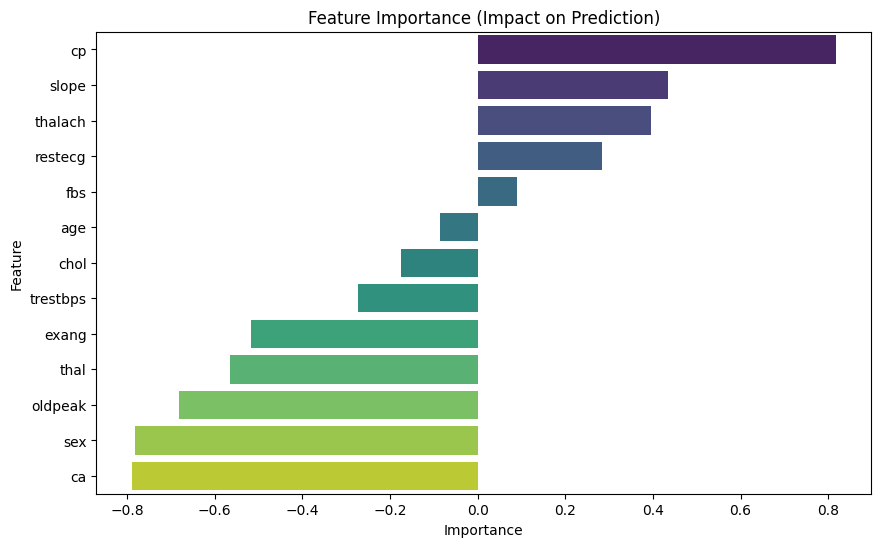

In [9]:
# Cell 5: Highlighting Important Features (Requirement)
import pandas as pd

# Get the importance of each feature from the model
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
importance = importance.sort_values(by='Importance', ascending=False)

print("### Top Medical Features Affecting Heart Disease Prediction ###")
print(importance)

# Visualizing feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance (Impact on Prediction)')
plt.show()